# **HEALTH INSURANCE PREMIUM PREDICTION**

The task is to predict the medical insurance charges incurred by an individual based on personal, health, lifestyle, and regional characteristics. This is a supervised regression problem because the output is a continuous numerical value. The analysis will use historical insurance data to understand cost patterns and develop a model that can estimate expected healthcare expenses for new customers.

### **Business Context**

Health insurance providers need to estimate the medical expenses likely to be incurred by an individual. Premiums and pricing decisions depend on customer characteristics and health-related risk factors. An accurate estimate helps the insurer price policies fairly, manage financial risk, and support consistent decision-making.

### **Objective**

The objective is to build a supervised machine-learning model that predicts an individual's medical insurance charges using demographic, lifestyle, and geographic information. The model should identify the main factors associated with healthcare costs and provide reliable estimates that can support premium calculation, risk assessment, customer segmentation, and business planning. Model performance will be evaluated using regression metrics such as Mean Squared Error (MSE) and the coefficient of determination ($R^2$).

### **Data Description**

The dataset contains individual-level health insurance records. Each row represents one policyholder or customer, and the target variable is `charges`, the individual's medical insurance cost.

The input variables are:

- `age`: age of the individual in years.
- `sex`: biological sex of the individual.
- `bmi`: body mass index, a measure related to body weight and height.
- `children`: number of dependents or children covered by the policy.
- `smoker`: smoking status of the individual.
- `region`: geographic region of residence.
- `charges`: medical insurance charges to be predicted.

The dataset includes both numerical variables (`age`, `bmi`, `children`, and `charges`) and categorical variables (`sex`, `smoker`, and `region`). Duplicate records are checked and removed before analysis. Categorical variables must be encoded before they can be used by a regression model.

# **INSTALLING AND IMPORTING LIBRARIES**

The required Python libraries are installed and imported. pandas and NumPy support data handling, Matplotlib and Seaborn support visualization, and scikit-learn provides linear regression, train-test splitting, categorical encoding, and evaluation metrics.

In [1]:
!pip install matplotlib seaborn scikit-learn pandas

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error, r2_score

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# **LOADING THE DATASET**

The insurance dataset is loaded from the CSV file using `pandas.read_csv()`. The data is stored in a pandas DataFrame named `data`, which allows it to be inspected, cleaned, visualized, and prepared for predictive modeling. Loading the data is the first step in understanding the structure and quality of the information available for predicting insurance charges.

In [3]:
data=pd.read_csv("C:\\Users\\ushan\\OneDrive\\Desktop\\GenAi\\Machine Learning\\insurance_prediction (1).csv")


# **Data Overview**

The initial dataset contains 1,338 rows and 7 columns. Each row represents an individual insurance policyholder, while the columns contain demographic, health, lifestyle, geographic, and cost information. The overview checks the dataset dimensions, sample records, data types, descriptive statistics, categorical-value distributions, and duplicate records before exploratory analysis and model development.

The shape output confirms the number of observations and variables available for analysis. This provides an initial view of the dataset size and helps determine whether the data is sufficient for exploratory analysis and regression modeling.

In [4]:
data.shape

(1338, 7)

The first few records provide a quick view of the dataset's structure, column names, value formats, and the relationship between customer attributes and insurance charges.

In [5]:
print(data.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


Displaying the first ten records gives a broader sample of the observations and helps verify that the imported data is readable and consistently organized.

In [6]:
data.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


The last ten records are inspected to confirm that the dataset was loaded completely and that the ending rows do not contain unexpected formatting or missing values.

In [7]:
data.tail(10)


,age,sex,bmi,children,smoker,region,charges
1328,23,female,24.225,2,no,northeast,22395.74424
1329,52,male,38.600,2,no,southwest,10325.20600
1330,57,female,25.740,2,no,southeast,12629.16560
1331,23,female,33.400,0,no,southwest,10795.93733
1332,52,female,44.700,3,no,southwest,11411.68500
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500
1337,61,female,29.070,0,yes,northwest,29141.36030


The data-information summary identifies the column names, number of non-null observations, data types, and memory usage. These details are important for detecting missing values and separating numerical variables from categorical variables before modeling.

In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


Descriptive statistics summarize the central tendency, spread, and range of the numerical variables. They help identify unusual values, variation in customer characteristics, and the scale of the target variable, `charges`.

In [9]:
data.describe()


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


The transposed summary makes the numerical statistics easier to compare across variables because each variable is displayed as a row with its count, mean, standard deviation, minimum, quartiles, and maximum.

In [10]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


The categorical summary describes the unique categories, most frequent category, and frequency of that category for variables such as sex, smoker, and region. This helps assess category balance and identify dominant groups.

In [11]:
data.describe(include='object').T

C:\Users\ushan\AppData\Local\Temp\ipykernel_10444\1286007417.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include='object').T


,count,unique,top,freq
sex,1338,2,male,676
smoker,1338,2,no,1064
region,1338,4,southeast,364


Duplicate records are reviewed before cleaning so that repeated observations can be identified and prevented from influencing descriptive analysis or model training more than once.

In [12]:
duplicate_rows=data[data.duplicated()]

print(f"Number of duplicate rows: {len(duplicate_rows)}")

duplicate_rows

Number of duplicate rows: 1


,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


The duplicate check identified one repeated record. The duplicate was removed so that the same policyholder information does not receive unintended extra influence during analysis or model training. The cleaned dataset contains 1,337 unique records and retains all 7 original variables.

In [13]:
data = data.drop_duplicates()

print(f"Shape after removing duplicates: {data.shape}  ")

Shape after removing duplicates: (1337, 7)  


# **EXPLORATORY DATA ANALYSIS**

Exploratory data analysis is used to understand the distributions of individual variables and the relationships between customer characteristics and insurance charges. These observations guide preprocessing and model selection.

## **Univariant Analysis**

Univariate analysis examines one variable at a time. The plots below describe the distribution of age, sex, BMI, smoking status, region, and medical charges, helping identify common values, imbalance, spread, and possible outliers.

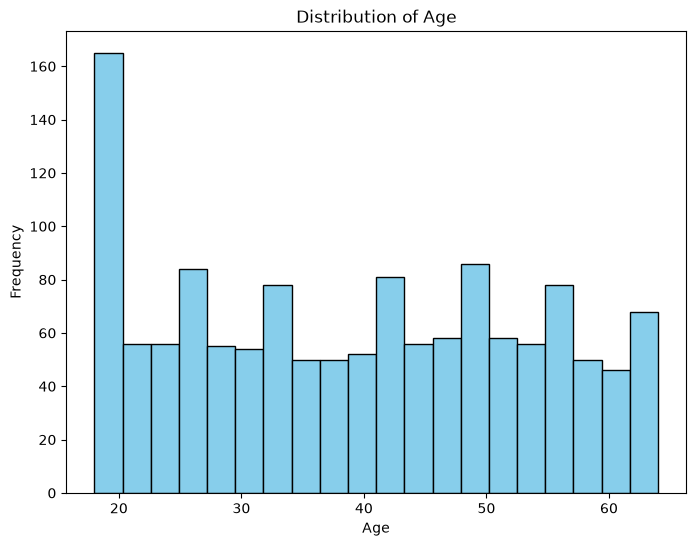

In [14]:
plt.figure(figsize=(8,6))
plt.hist(data['age'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

The age distribution is plotted again with a different figure size to make the shape and concentration of ages easier to inspect. This repetition supports visual confirmation of the age pattern in the dataset.

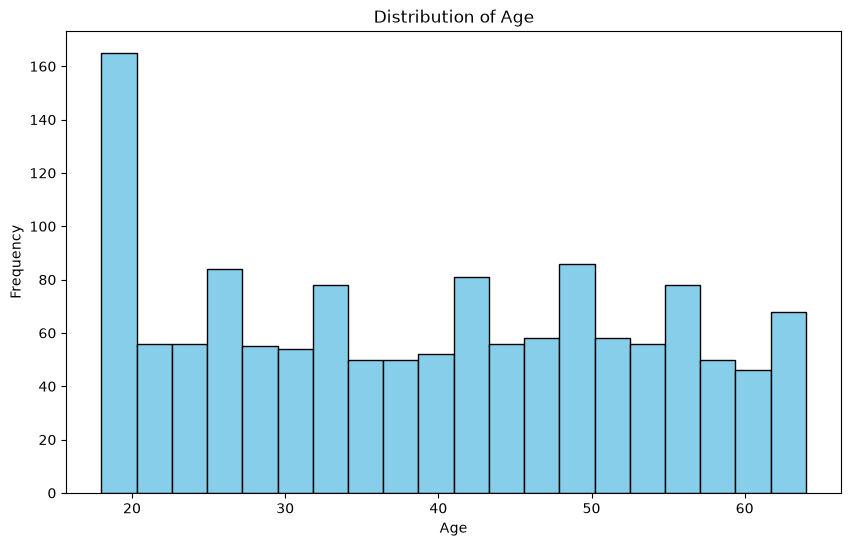

In [15]:
plt.figure(figsize=(10, 6))
plt.hist(data['age'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

The gender count plot compares the number of male and female policyholders. Understanding the group balance is useful when interpreting charge comparisons and checking whether one category is substantially underrepresented.

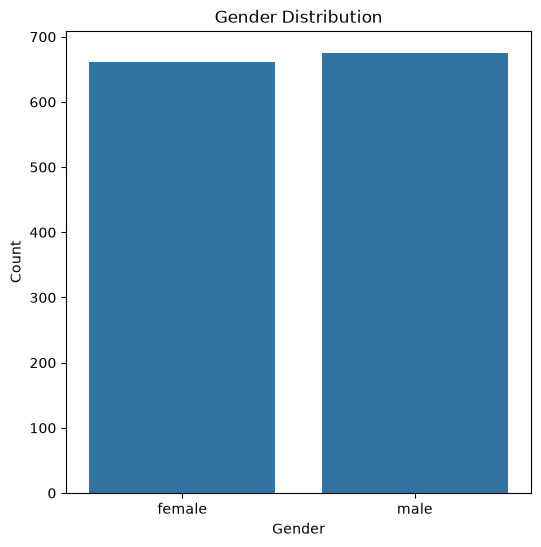

In [16]:
plt.figure(figsize=(6, 6))
sns.countplot(x='sex', data=data)
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

The BMI histogram with a density curve shows the typical BMI range, concentration, and overall distribution shape. It can also reveal skewness or extreme BMI values that may affect insurance charges.

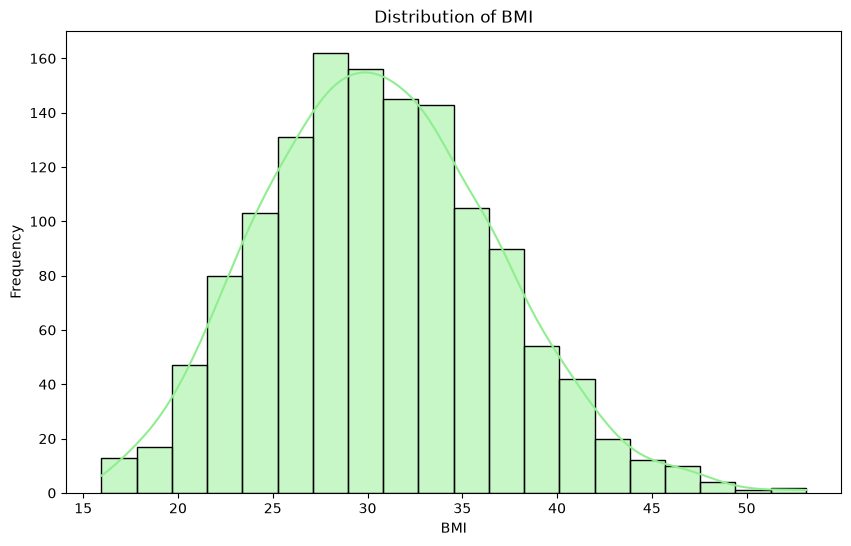

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(data['bmi'], bins=20, kde=True, color='lightgreen')
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()

The smoking-status count plot shows the relative number of smokers and non-smokers. This distribution is important because smoking is a potentially strong risk factor and may create meaningful differences in medical charges.

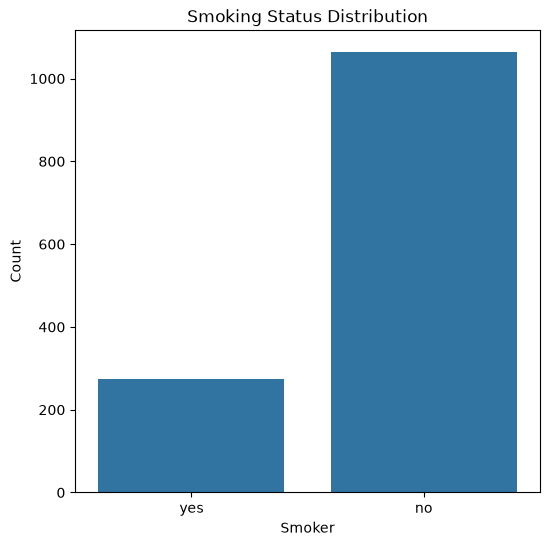

In [18]:
plt.figure(figsize=(6, 6))
sns.countplot(x='smoker', data=data)
plt.title('Smoking Status Distribution')
plt.xlabel('Smoker')
plt.ylabel('Count')
plt.show()

The region count plot compares the number of policyholders across geographic areas. It helps determine whether the regional categories are reasonably represented for later comparison and encoding.

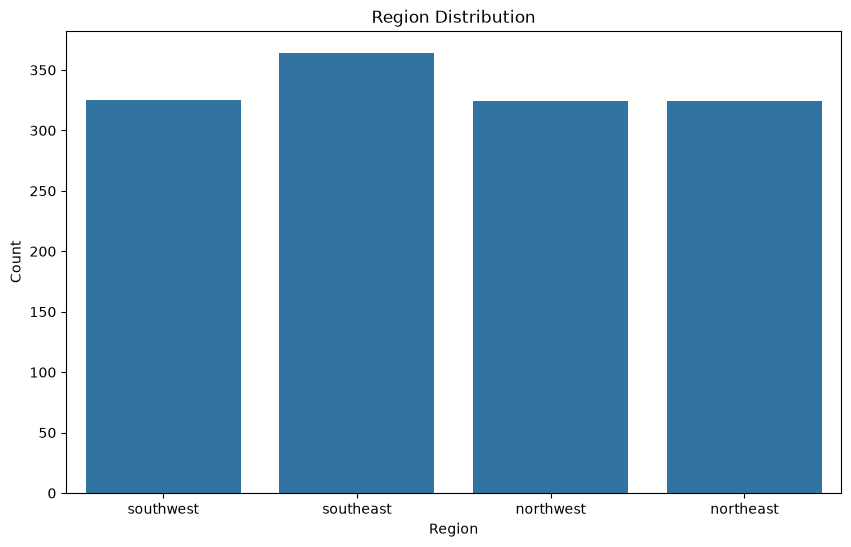

In [19]:
plt.figure(figsize=(10, 6))
sns.countplot(x='region', data=data)
plt.title('Region Distribution')
plt.xlabel('Region')
plt.ylabel('Count')
plt.show()

The charges boxplot summarizes the distribution of medical insurance costs, including the median, middle spread, and potential high-cost outliers. A wide or skewed distribution indicates that a small number of policyholders may incur substantially higher costs.

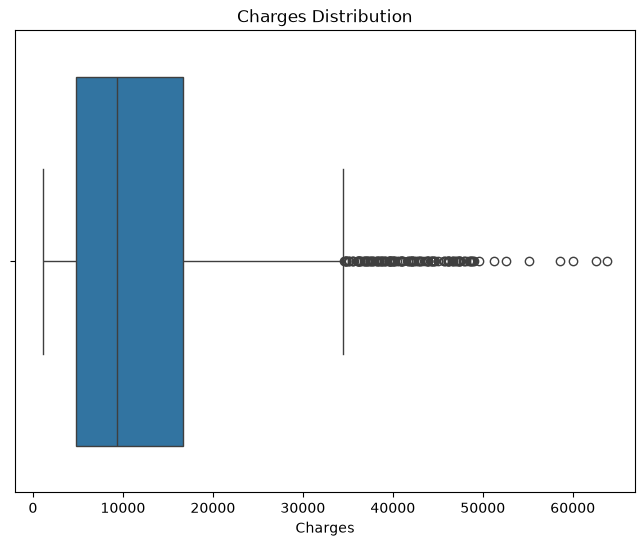

In [20]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='charges', data=data)
plt.title('Charges Distribution')
plt.xlabel('Charges')
plt.show()

## **BIVARIANT ANALYSIS**

Bivariate analysis examines how two variables move together, with particular attention to their relationship with the target variable, `charges`. These comparisons help identify potentially useful predictors and visible group differences.

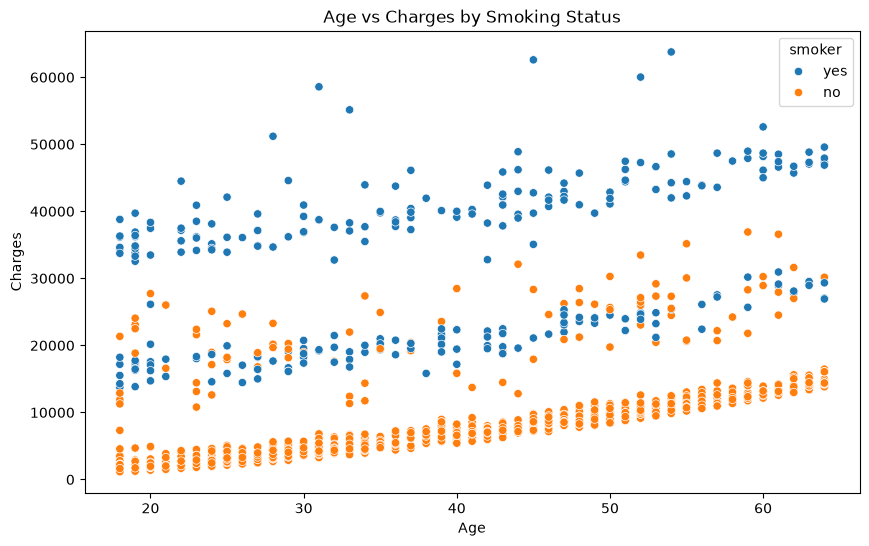

In [21]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='charges', data=data, hue='smoker')
plt.title('Age vs Charges by Smoking Status')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.show()

The age-versus-charges scatter plot separates observations by smoking status. It helps assess whether charges tend to increase with age and whether smokers and non-smokers follow different cost patterns.

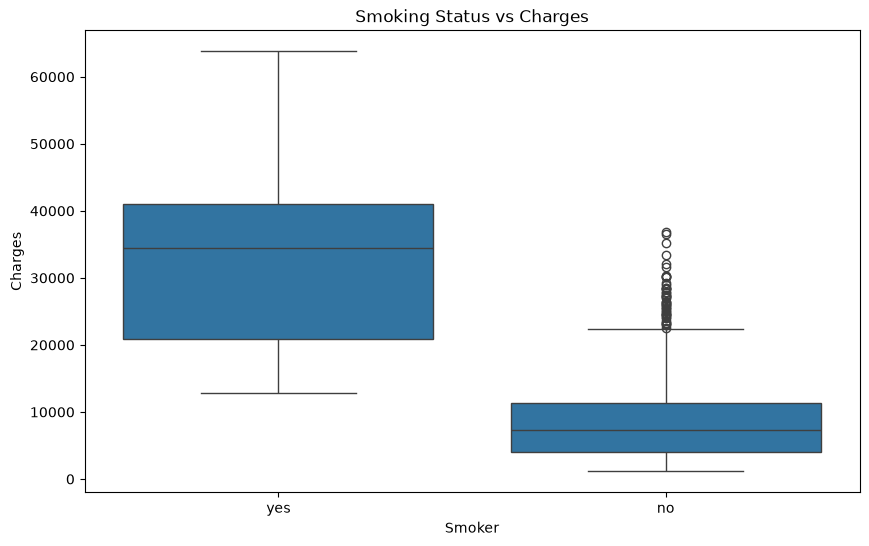

In [22]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='smoker', y='charges', data=data)
plt.title('Smoking Status vs Charges')
plt.xlabel('Smoker')
plt.ylabel('Charges')
plt.show()

The smoking-status boxplot compares the distribution of insurance charges for smokers and non-smokers. Differences in medians, spread, and outliers indicate whether smoking status is likely to be an important predictor of medical costs.

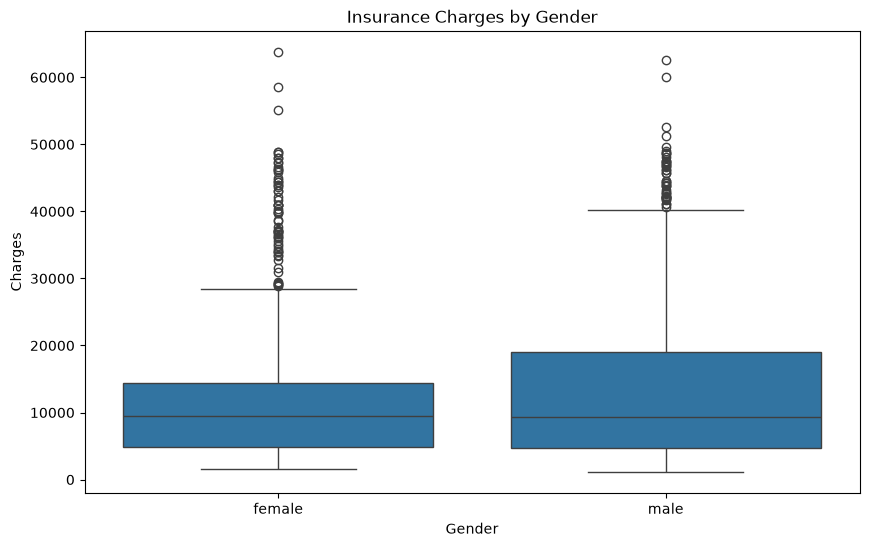

In [23]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='sex', y='charges', data=data)
plt.title('Insurance Charges by Gender')
plt.xlabel('Gender')
plt.ylabel('Charges')
plt.show()



The gender-based boxplot compares insurance-charge distributions between the two sex categories. It is used to examine differences in typical charges and variability while recognizing that a visible association does not by itself establish causation.

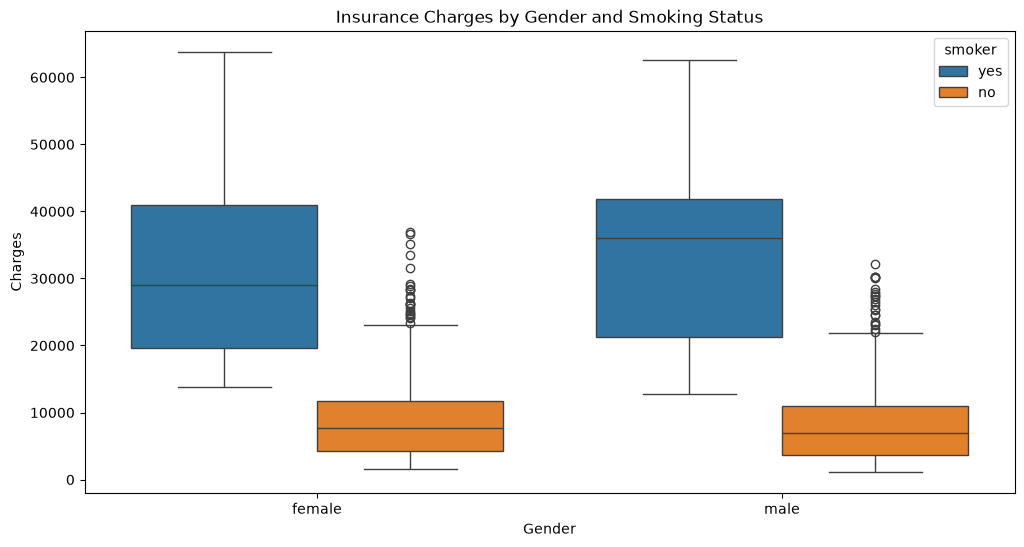

In [24]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='sex',y='charges',hue='smoker', data=data)
plt.title('Insurance Charges by Gender and Smoking Status')
plt.xlabel('Gender')
plt.ylabel('Charges')
plt.show()

This grouped boxplot examines insurance charges jointly by sex and smoking status. It helps reveal whether the apparent effect of smoking is consistent across gender groups and whether interactions may exist between these categorical variables.

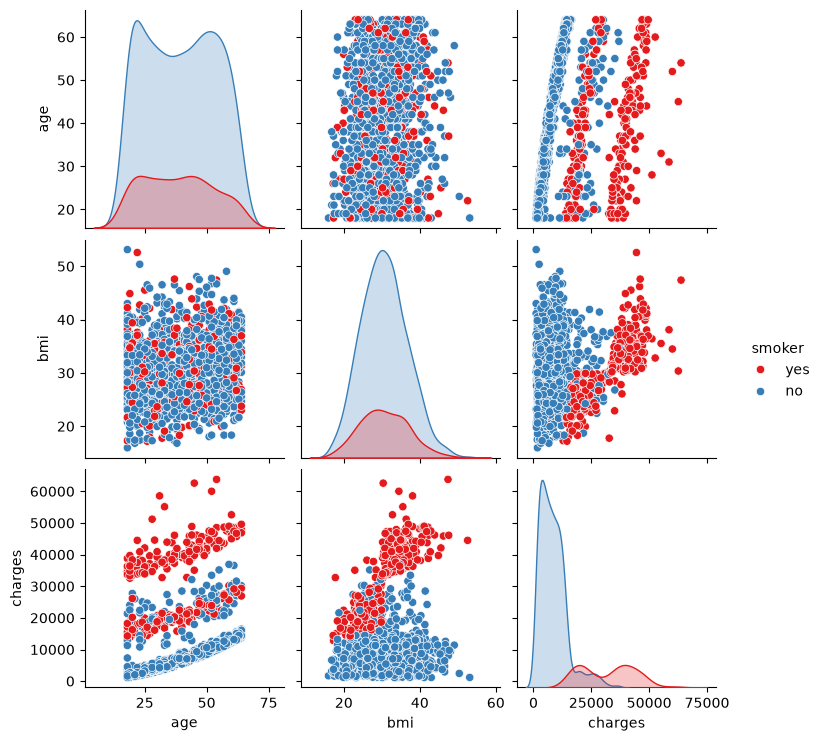

In [25]:
sns.pairplot(data,vars=['age','bmi','charges'], hue='smoker', palette='Set1')
plt.show()

The pairplot compares pairwise relationships among age, BMI, and charges, with points colored by smoking status. It provides a combined view of numerical associations, distributions, clusters, and possible outliers.

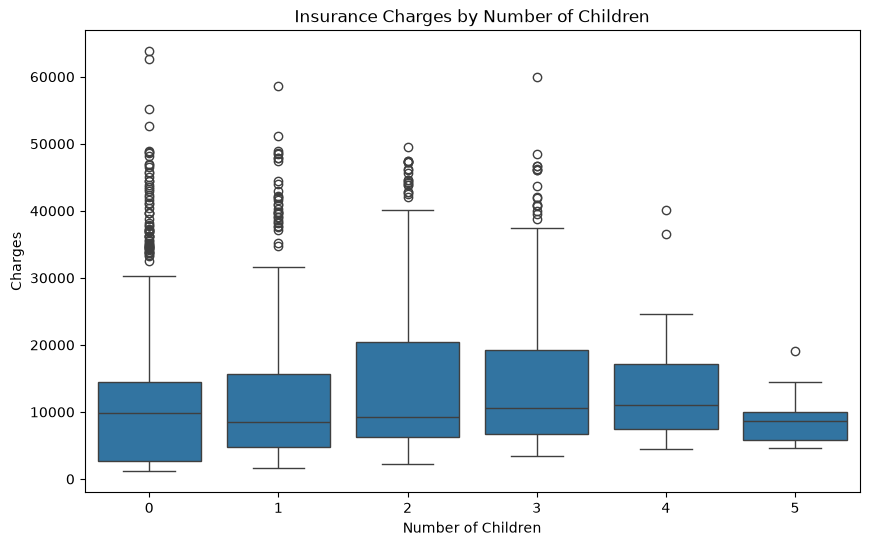

In [26]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='children', y='charges', data=data)
plt.title('Insurance Charges by Number of Children')
plt.xlabel('Number of Children')
plt.ylabel('Charges')
plt.show()

The boxplot by number of children compares insurance-charge distributions across dependent counts. This helps evaluate whether family size is associated with different cost levels or whether the groups have substantial overlap.

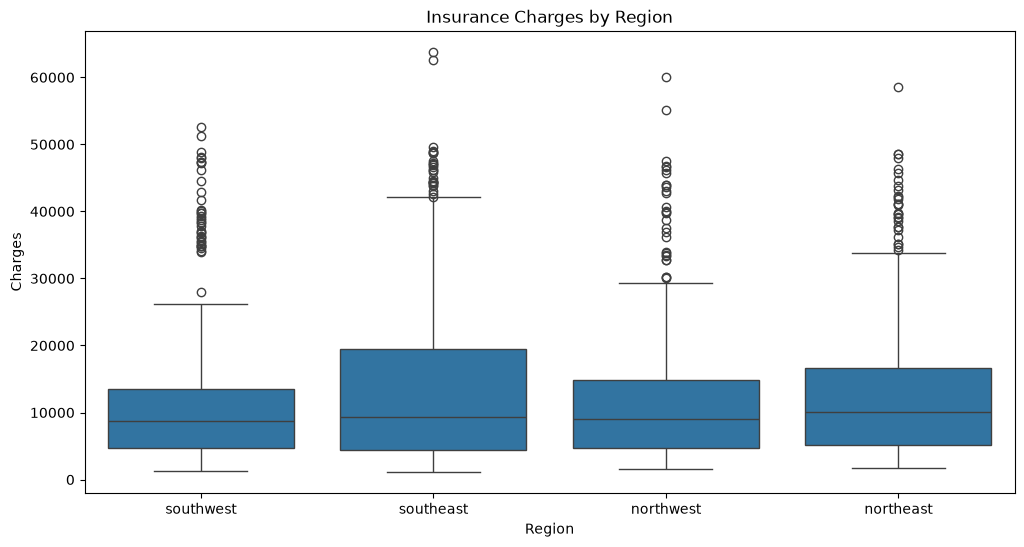

In [27]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='region', y='charges', data=data)
plt.title('Insurance Charges by Region')
plt.xlabel('Region')
plt.ylabel('Charges')
plt.show()


The regional boxplot compares medical-charge distributions across geographic areas. It helps identify possible regional variation while showing the degree of overlap and variability within each region.

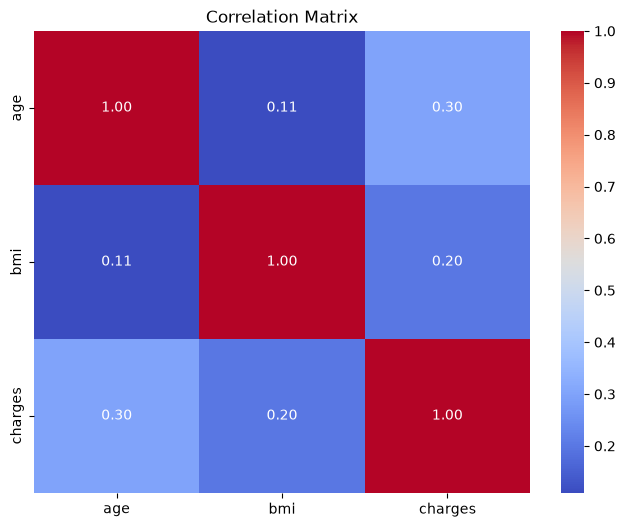

In [28]:
numerical_cols = ['age','bmi','charges']
correlation_matrix = data[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

The heatmap provides a visual summary of pairwise linear correlations among the numerical variables. Stronger absolute correlations may indicate useful predictors, while weak correlations do not necessarily rule out nonlinear or interaction effects.

The preprocessing section prepares the dataset for machine learning by converting categorical information into numerical form, defining the target, and creating independent training and testing samples.

The preprocessing stage converts the cleaned exploratory dataset into a form that can be used by a regression algorithm. It includes transforming categorical variables and separating predictors from the continuous target.

Categorical encoding is required because linear regression operates on numerical inputs. The encoded columns retain category information while making the data compatible with the model.

In [29]:
data=pd.get_dummies(data,columns=['sex','smoker','region'], drop_first=True, dtype=int)

One-hot encoding creates numerical indicator columns for the categorical variables. With `drop_first=True`, one category from each variable is used as the reference category, which avoids redundant dummy columns and allows the regression coefficients to be interpreted relative to those references.

In [30]:
data.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


The encoded preview confirms that the original categorical fields have been replaced by numerical dummy variables while the numerical features and target remain available for modeling.

## *TRAIN TEST SPLIT*

In [31]:
X= data.drop('charges', axis=1)
y= data['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

The data is divided into predictor variables, `X`, and the target variable, `y`. A 70% training and 30% testing split is used so the models can learn from one subset and be evaluated on previously unseen observations.

In [32]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (935, 8)
X_test shape: (402, 8)
y_train shape: (935,)
y_test shape: (402,)


The printed shapes verify that the train-test split was created correctly and that the predictor and target partitions have matching row counts within each subset. This check helps prevent data-alignment errors before model fitting.

# **MODEL BUILDING**

Three linear-regression models are developed with progressively richer predictor sets. Comparing simple and full models shows whether additional demographic, lifestyle, and regional information improves prediction beyond age alone.

###  MODEL EVALUATION CRITERION

A results table is initialized to store training and testing performance for every model. Keeping the metrics together makes it easier to compare predictive accuracy and identify possible overfitting.

In [33]:
model_eval_results=pd.DataFrame(columns=['Model','Train_MSE', 'Train_R2','Test_MSE', 'Test_R2'])

## **Model 1**

Model 1 is a baseline linear-regression model that uses age as the only predictor. Its purpose is to measure how much of the variation in insurance charges can be explained by age alone.

In [34]:
X_train_m1 = X_train[['age']]
X_test_m1 = X_test[['age']]

model_1 = LinearRegression()
model_1.fit(X_train_m1, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[238.82]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['age']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3719
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


The model is fitted using the training observations and the age feature. The learned intercept and coefficient define the estimated change in charges associated with a one-year increase in age, assuming the simple linear relationship.

In [35]:
print(f'Linear Regression Equation: charges = {model_1.intercept_:.2f} + {model_1.coef_[0]:.2f} * Age')

Linear Regression Equation: charges = 3718.81 + 238.82 * Age


The displayed equation translates the fitted baseline model into an interpretable business form: the intercept is the estimated charge at age zero, and the age coefficient is the estimated average change in charges for each additional year of age. The intercept may not have practical meaning outside the observed age range.

In [36]:
y_train_pred_m1 = model_1.predict(X_train_m1)
y_test_pred_m1 = model_1.predict(X_test_m1)

train_mse_m1 = mean_squared_error(y_train, y_train_pred_m1)
train_r2_m1 = r2_score(y_train, y_train_pred_m1)

test_mse_m1 = mean_squared_error(y_test, y_test_pred_m1)
test_r2_m1 = r2_score(y_test, y_test_pred_m1)

model_eval_results.loc[len(model_eval_results)] = ['Model 1 (Age Only)', train_mse_m1, train_r2_m1, test_mse_m1, test_r2_m1]

model_eval_results

,Model,Train_MSE,Train_R2,Test_MSE,Test_R2
0,Model 1 (Age Only),1.246248e+08,0.082229,1.545219e+08,0.096985


## **MODEL 2**

Model 2 extends the baseline by using both age and BMI. This tests whether adding a health-related numerical feature improves the explanation and prediction of insurance charges.

In [37]:
X_train_m2 = X_train[['age', 'bmi']]
X_test_m2 = X_test[['age', 'bmi']]

model_2 = LinearRegression()
model_2.fit(X_train_m2, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[227.4 ,254.94]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['age','bmi']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-3642
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


The second model is trained with age and BMI as predictors. Each coefficient estimates the expected change in charges associated with that feature while holding the other included feature constant.

In [38]:
print(f'Linear Regression Equation: Charges = {model_2.intercept_:.2f} + {model_2.coef_[0]:.2f} * Age + {model_2.coef_[1]:.2f} * BMI')

Linear Regression Equation: Charges = -3641.79 + 227.40 * Age + 254.94 * BMI


The equation reports the intercept and the coefficients for age and BMI. This makes the model transparent and allows the direction and approximate size of each numerical feature's linear contribution to be examined.

In [39]:
y_train_pred_m2 = model_2.predict(X_train_m2)
y_test_pred_m2 = model_2.predict(X_test_m2)

train_mse_m2 = mean_squared_error(y_train, y_train_pred_m2)
train_r2_m2 = r2_score(y_train, y_train_pred_m2)

test_mse_m2 = mean_squared_error(y_test, y_test_pred_m2)
test_r2_m2 = r2_score(y_test, y_test_pred_m2)

model_eval_results.loc[len(model_eval_results)] = ['Model 2 (Age Only)', train_mse_m2, train_r2_m2, test_mse_m2, test_r2_m2]

model_eval_results

,Model,Train_MSE,Train_R2,Test_MSE,Test_R2
0,Model 1 (Age Only),1.246248e+08,0.082229,1.545219e+08,0.096985
1,Model 2 (Age Only),1.222942e+08,0.099392,1.471034e+08,0.140338


The Model 2 evaluation compares its predictions with the actual charges on both training and testing data. The resulting metrics show whether BMI provides additional predictive value beyond the age-only baseline.

## **MODEL 3**

Model 3 uses all encoded predictors available in the training data. It represents the most complete linear model in this notebook and tests whether demographic, lifestyle, family, and regional variables improve prediction together.

In [40]:
model_3=LinearRegression()
model_3.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 251.25, 328.38, 522.16,...,-465.75,-936.1 ,-765.58]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['age','bmi','children',...,'region_northwest','region_southeast', 'region_southwest']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.152e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


The full model is fitted using all columns in `X_train`. Because the categorical variables were encoded earlier, the regression algorithm can estimate a coefficient for each retained dummy variable as well as for the numerical predictors.

In [41]:
equation = f'Charges = {model_3.intercept_:.2f}'
for i, col in enumerate(X_train.columns):
    equation += f' + {model_3.coef_[i]:.2f} * {col}'

    print(f'Linear Regression Equation: {equation}')

Linear Regression Equation: Charges = -11516.78 + 251.25 * age
Linear Regression Equation: Charges = -11516.78 + 251.25 * age + 328.38 * bmi
Linear Regression Equation: Charges = -11516.78 + 251.25 * age + 328.38 * bmi + 522.16 * children
Linear Regression Equation: Charges = -11516.78 + 251.25 * age + 328.38 * bmi + 522.16 * children + -111.91 * sex_male
Linear Regression Equation: Charges = -11516.78 + 251.25 * age + 328.38 * bmi + 522.16 * children + -111.91 * sex_male + 22874.45 * smoker_yes
Linear Regression Equation: Charges = -11516.78 + 251.25 * age + 328.38 * bmi + 522.16 * children + -111.91 * sex_male + 22874.45 * smoker_yes + -465.75 * region_northwest
Linear Regression Equation: Charges = -11516.78 + 251.25 * age + 328.38 * bmi + 522.16 * children + -111.91 * sex_male + 22874.45 * smoker_yes + -465.75 * region_northwest + -936.10 * region_southeast
Linear Regression Equation: Charges = -11516.78 + 251.25 * age + 328.38 * bmi + 522.16 * children + -111.91 * sex_male + 22874

The generated equation lists the intercept and every model coefficient. Each coefficient represents the expected change in charges for a one-unit increase in a numerical feature or the difference from the relevant reference category for an encoded categorical feature, holding other predictors constant.

In [42]:
y_train_pred_m3 = model_3.predict(X_train)
y_test_pred_m3 = model_3.predict(X_test)

train_mse_m3 = mean_squared_error(y_train, y_train_pred_m3)
train_r2_m3 = r2_score(y_train, y_train_pred_m3)

test_mse_m3 = mean_squared_error(y_test, y_test_pred_m3)
test_r2_m3 = r2_score(y_test, y_test_pred_m3)

model_eval_results.loc[len(model_eval_results)] = ['Model 3 (Age Only)', train_mse_m3, train_r2_m3, test_mse_m3, test_r2_m3]

model_eval_results

,Model,Train_MSE,Train_R2,Test_MSE,Test_R2
0,Model 1 (Age Only),1.246248e+08,0.082229,1.545219e+08,0.096985
1,Model 2 (Age Only),1.222942e+08,0.099392,1.471034e+08,0.140338
2,Model 3 (Age Only),3.581293e+07,0.736264,3.894017e+07,0.772436


The Model 3 evaluation records predictions from the full feature set and compares them with observed charges on both training and testing data. These values are added to the common results table for direct comparison with Models 1 and 2.

# *Model Comparison and Final Model Selection*

In [43]:
model_eval_results

,Model,Train_MSE,Train_R2,Test_MSE,Test_R2
0,Model 1 (Age Only),1.246248e+08,0.082229,1.545219e+08,0.096985
1,Model 2 (Age Only),1.222942e+08,0.099392,1.471034e+08,0.140338
2,Model 3 (Age Only),3.581293e+07,0.736264,3.894017e+07,0.772436


## *Final Model Selection: Model 3 (Full-Feature Linear Regression)*

**Model 3 is the best model for predicting insurance charges.** It uses all available encoded predictors, including age, BMI, children, smoking status, sex, and region.

The held-out test-set results are:

- **Test MSE:** 38,940,170, the lowest of the three models
- **Test R²:** 0.772, the highest of the three models

*Model 1*, which uses only age, has a test R² of 0.097, while *Model 2*, which uses age and BMI, has a test R² of 0.140. *Model 3* explains approximately **77.2% of the variation** in insurance charges, showing that the additional health, lifestyle, demographic, and regional variables provide substantial predictive value.

***Model 3*** is therefore selected because it produces the most accurate predictions on unseen data and generalizes better than the simpler models. Before production use, the model should be checked with cross-validation and monitored for changes in prediction performance.